# Compactness comparison across $\beta$, $\lambda_{\rm GB}$, and $\mu$

Loads all available runs and lets you select which parameter combinations to plot.

**Compactness:** Only evaluated for $1.6 \leq \ln(a) \leq 3$ (oscillons formed). For each run we report the **mean** compactness in that window, with error bars from the **minimum** to **maximum** value (oscillation range).

In [1]:
import sys, os, re, glob
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, PROJECT_ROOT)

from core.grid import Grid
from core.spacing import CubicSpacing
from core.statevector import StateVector
from matter.scalarmatter_MG import ScalarMatter
from backgrounds.sphericalbackground import FlatSphericalBackground
from bssn.oscillondiagnostic import get_oscillon_diagnostic

DATA_DIR = os.path.join(os.environ.get("VSC_DATA", os.getcwd()), "oscillon_runs")
print(f"DATA_DIR = {DATA_DIR}")

DATA_DIR = /data/leuven/384/vsc38419/oscillon_runs


## 0 — List all run directories (with perturbation)

Below: every run directory under `DATA_DIR` with parsed **λ_GB**, **μ**, **β**, **perturbation** (amp), **width** (R), and **dr**. Runs with the same (lgb, μ, β) but different amp/R/dr appear as separate lines.

In [2]:
# List all run directories with parsed parameters (including perturbation)
runs_info = []
for run_dir in sorted(glob.glob(os.path.join(DATA_DIR, "lgb*"))):
    tag = os.path.basename(run_dir)
    has_solution = os.path.exists(os.path.join(run_dir, "solution.npy"))
    m_lgb = re.search(r"lgb([0-9eE.+-]+)", tag)
    m_mu  = re.search(r"mu([0-9eE.+-]+)", tag)
    m_amp = re.search(r"_amp([0-9eE.+-]+)", tag)
    m_R   = re.search(r"_R([0-9eE.+-]+)", tag)
    m_dr  = re.search(r"_dr([0-9eE.+-]+)", tag)
    m_beta = re.search(r"quadratic_(\d+\.?\d*)", tag)
    if not m_lgb or not m_mu:
        continue
    lgb = float(m_lgb.group(1))
    mu  = float(m_mu.group(1))
    amp = float(m_amp.group(1)) if m_amp else None
    R   = float(m_R.group(1)) if m_R else None
    dr  = float(m_dr.group(1)) if m_dr else None
    beta = float(m_beta.group(1)) if m_beta else (250.0 if "_linear" not in tag else None)
    if "_linear" in tag:
        beta = None
    runs_info.append({
        "tag": tag,
        "lgb": lgb, "mu": mu, "beta": beta,
        "perturbation": amp, "width": R, "dr": dr,
        "has_solution": has_solution,
    })

# Print table (compact)
fmt = "{:>6} {:>6} {:>8} {:>12} {:>6} {:>8}  {}"
print(fmt.format("lgb", "mu", "beta", "perturbation", "width", "dr", "tag"))
print("-" * 90)
for r in runs_info:
    amp_s = f"{r['perturbation']:.2e}" if r['perturbation'] is not None else "?"
    R_s   = f"{r['width']}" if r['width'] is not None else "?"
    dr_s  = f"{r['dr']}" if r['dr'] is not None else "?"
    beta_s = f"{int(r['beta'])}" if r['beta'] is not None else "linear"
    print(fmt.format(r["lgb"], r["mu"], beta_s, amp_s, R_s, dr_s, r["tag"]))
print(f"\nTotal: {len(runs_info)} run directory(ies)")

   lgb     mu     beta perturbation  width       dr  tag
------------------------------------------------------------------------------------------
  -1.0   0.08        0    -2.00e-02    3.0   0.0625  lgb-1.0_mu0.08_a0.2_b0.4_amp-0.02_R3_dr0.0625_quadratic_0
 -10.0   0.08       10    -2.00e-02    3.0   0.0625  lgb-10.0_mu0.08_a0.2_b0.4_amp-0.02_R3_dr0.0625_quadratic_10
 -15.0   0.08       10    -2.00e-02    3.0   0.0625  lgb-15.0_mu0.08_a0.2_b0.4_amp-0.02_R3_dr0.0625_quadratic_10
  -2.0   0.08        0    -2.00e-02    3.0   0.0625  lgb-2.0_mu0.08_a0.2_b0.4_amp-0.02_R3_dr0.0625_quadratic_0
 -20.0   0.08       10    -2.00e-02    3.0   0.0625  lgb-20.0_mu0.08_a0.2_b0.4_amp-0.02_R3_dr0.0625_quadratic_10
 -25.0   0.08       10    -2.00e-02    3.0   0.0625  lgb-25.0_mu0.08_a0.2_b0.4_amp-0.02_R3_dr0.0625_quadratic_10
  -3.0   0.08        0    -2.00e-02    3.0   0.0625  lgb-3.0_mu0.08_a0.2_b0.4_amp-0.02_R3_dr0.0625_quadratic_0
  -4.0   0.08        0    -2.00e-02    3.0   0.0625  lgb-4.0_mu0.08

## 1 — Discover and load all runs

In [3]:
scalar_mu = 1
r_max = 150
min_dr = 1 / 16
max_dr = 2
a_mg = 0.2
b_mg = 0.4
chi0 = 0.15

# Compactness is only meaningful after oscillons have formed; use window 1.6 <= ln(a) <= 3
# and report mean with error bars from min to max in that window.
LN_A_COMPACTNESS_MIN = 1.6
LN_A_COMPACTNESS_MAX = 3.0

def compactness_in_window(osc):
    """Return (C_mean, C_min, C_max) for 1.6 <= ln(a) <= 3; (nan, nan, nan) if no points."""
    ln_a = osc["ln_a"]
    C = osc["C"]
    mask = (ln_a >= LN_A_COMPACTNESS_MIN) & (ln_a <= LN_A_COMPACTNESS_MAX)
    if not np.any(mask):
        return np.nan, np.nan, np.nan
    c_vals = C[mask]
    return np.mean(c_vals), np.min(c_vals), np.max(c_vals)

all_runs = {}  # (lgb, mu, beta, amp, width) -> dict

for run_dir in sorted(glob.glob(os.path.join(DATA_DIR, "lgb*"))):
    tag = os.path.basename(run_dir)
    if not os.path.exists(os.path.join(run_dir, "solution.npy")):
        continue

    m_lgb = re.search(r"lgb([0-9eE.+-]+)", tag)
    m_mu  = re.search(r"mu([0-9eE.+-]+)", tag)
    m_amp = re.search(r"_amp([0-9eE.+-]+)", tag)
    m_R   = re.search(r"_R([0-9eE.+-]+)", tag)
    if not m_lgb or not m_mu:
        continue
    lgb = float(m_lgb.group(1))
    mu  = float(m_mu.group(1))
    amp = float(m_amp.group(1)) if m_amp else -0.02
    width = float(m_R.group(1)) if m_R else 3.0

    # Extract beta from coupling suffix like "_quadratic_50"
    m_beta = re.search(r"quadratic_(\d+\.?\d*)", tag)
    beta = float(m_beta.group(1)) if m_beta else 250.0

    # Extract coupling type
    if "_linear" in tag:
        coupling = "linear"
        beta = None
    elif m_beta:
        coupling = f"quadratic_{int(beta)}"
    else:
        coupling = "quadratic"

    sol = np.load(os.path.join(run_dir, "solution.npy"))
    t   = np.load(os.path.join(run_dir, "t.npy"))

    # Build grid for this mu
    matter_i = ScalarMatter(scalar_mu, mu)
    sv_i = StateVector(matter_i)
    spacing_i = CubicSpacing(**CubicSpacing.get_parameters(r_max, min_dr, max_dr))
    grid_i = Grid(spacing_i, sv_i)
    bg_i = FlatSphericalBackground(grid_i.r)

    diag_path = os.path.join(run_dir, "diagnostics.npz")
    if os.path.exists(diag_path):
        osc = dict(np.load(diag_path, allow_pickle=True))
        status = "loaded"
    else:
        status = "computing"
        params = (lgb, a_mg, b_mg, chi0, coupling)
        osc = get_oscillon_diagnostic(
            sol, t, grid_i, bg_i,
            ScalarMatter(scalar_mu, mu),
            params, surface_threshold=0.05, r_max_diag=100.0,
        )
        np.savez(os.path.join(run_dir, "diagnostics.npz"), **osc)

    key = (lgb, mu, beta, amp, width)
    C_mean, C_min, C_max = compactness_in_window(osc)
    all_runs[key] = dict(
        osc=osc, t=t, tag=tag, lgb=lgb, mu=mu, beta=beta, coupling=coupling,
        amp=amp, width=width, C_mean=C_mean, C_min=C_min, C_max=C_max,
    )
    beta_str = f"beta={int(beta)}" if beta is not None else "linear"
    if np.isnan(C_mean):
        print(f"  lgb={lgb:6.1f}, mu={mu:.2f}, {beta_str:>10s}, amp={amp}, R={width} — {status} — C: no data in ln(a)\u2208[1.6,3]  ({len(t)} steps)")
    else:
        print(f"  lgb={lgb:6.1f}, mu={mu:.2f}, {beta_str:>10s}, amp={amp}, R={width} — {status} — C = {C_mean:.6e}  [{C_min:.6e}, {C_max:.6e}]  ({len(t)} steps)")
    del sol

print(f"\nTotal: {len(all_runs)} run(s) loaded")

  lgb=  -1.0, mu=0.08,     beta=0, amp=-0.02, R=3.0 — loaded — C = 7.758736e-03  [4.491191e-03, 1.580684e-02]  (1000 steps)
  lgb= -10.0, mu=0.08,    beta=10, amp=-0.02, R=3.0 — loaded — C = 6.993776e-03  [4.080812e-03, 1.478561e-02]  (1000 steps)
  lgb= -15.0, mu=0.08,    beta=10, amp=-0.02, R=3.0 — loaded — C = 1.521577e-02  [3.842874e-03, 9.568515e-01]  (1000 steps)
  lgb=  -2.0, mu=0.08,     beta=0, amp=-0.02, R=3.0 — loaded — C = 7.689263e-03  [4.469194e-03, 1.563384e-02]  (1000 steps)
  lgb= -20.0, mu=0.08,    beta=10, amp=-0.02, R=3.0 — loaded — C: no data in ln(a)∈[1.6,3]  (3 steps)
  lgb= -25.0, mu=0.08,    beta=10, amp=-0.02, R=3.0 — loaded — C: no data in ln(a)∈[1.6,3]  (3 steps)
  lgb=  -3.0, mu=0.08,     beta=0, amp=-0.02, R=3.0 — loaded — C = 7.623177e-03  [4.379965e-03, 1.532642e-02]  (1000 steps)
  lgb=  -4.0, mu=0.08,     beta=0, amp=-0.02, R=3.0 — loaded — C = 7.554460e-03  [4.323957e-03, 1.515512e-02]  (1000 steps)
  lgb=  -5.0, mu=0.08,     beta=0, amp=-0.02, R=3.0 

## 2 — Select runs to plot

Edit `selected` to choose which `(lgb, mu, beta, amp, width)` combinations appear on the plot.  
Run the cell below to see all available keys, then copy the ones you want.

In [4]:
print("Available runs (compactness: mean in ln(a)∈[1.6, 3], error bar: min–max):")
print(f"{'lgb':>8s}  {'mu':>6s}  {'beta':>8s}  {'amp':>10s}  {'R':>5s}  {'coupling':>15s}  {'C_mean':>12s}  {'C_min':>12s}  {'C_max':>12s}  {'T':>8s}")
print("-" * 120)
for key, data in sorted(all_runs.items()):
    lgb, mu, beta, amp, width = key
    C_mean, C_min, C_max = data["C_mean"], data["C_min"], data["C_max"]
    T_end = data["t"][-1]
    beta_str = f"{int(beta)}" if beta is not None else "—"
    c_mean_s = f"{C_mean:.6e}" if not np.isnan(C_mean) else "—"
    c_min_s = f"{C_min:.6e}" if not np.isnan(C_min) else "—"
    c_max_s = f"{C_max:.6e}" if not np.isnan(C_max) else "—"
    print(f"{lgb:8.1f}  {mu:6.2f}  {beta_str:>8s}  {amp:10.3f}  {width:5.1f}  {data['coupling']:>15s}  {c_mean_s:>12s}  {c_min_s:>12s}  {c_max_s:>12s}  {T_end:8.1f}")

Available runs (compactness: mean in ln(a)∈[1.6, 3], error bar: min–max):
     lgb      mu      beta         amp      R         coupling        C_mean         C_min         C_max         T
------------------------------------------------------------------------------------------------------------------------
   -25.0    0.08        10      -0.020    3.0     quadratic_10             —             —             —       1.6
   -20.0    0.08        10      -0.020    3.0     quadratic_10             —             —             —       1.6
   -15.0    0.08        10      -0.020    3.0     quadratic_10  1.521577e-02  3.842874e-03  9.568515e-01     799.2
   -10.0    0.08        10      -0.020    3.0     quadratic_10  6.993776e-03  4.080812e-03  1.478561e-02     799.2
    -9.0    0.08        10      -0.020    3.0     quadratic_10  7.122200e-03  4.134224e-03  1.483923e-02     799.2
    -8.0    0.08        10      -0.020    3.0     quadratic_10  7.273640e-03  4.168293e-03  1.478943e-02     799.2


In [130]:
# ── Select which runs to plot ─────────────────────────────────────────────
# Key format: (lgb, mu, beta, amp, width)
# Set to None to plot everything, or filter by conditions.
# Default perturbation: amp=-0.02, R=3.0

DEFAULT_AMP = -0.02 #-0.05
DEFAULT_WIDTH = 3.0
lijst = [-15, -10, -5, 0, 5, 10, 15]
betaval = 10

# All beta=50 runs with default perturbation
#selected = [k for k in all_runs if k[2] == betaval and k[3] == DEFAULT_AMP and k[4] == DEFAULT_WIDTH]

selected = [k for k in all_runs if k[2] == betaval and k[0] in lijst and k[3] == DEFAULT_AMP and k[4] == DEFAULT_WIDTH]



#selected = [k for k in all_runs if k[1] == 0.08]   # all mu=0.08 runs
#selected = None                                      # plot all


## 3 — Compactness time series

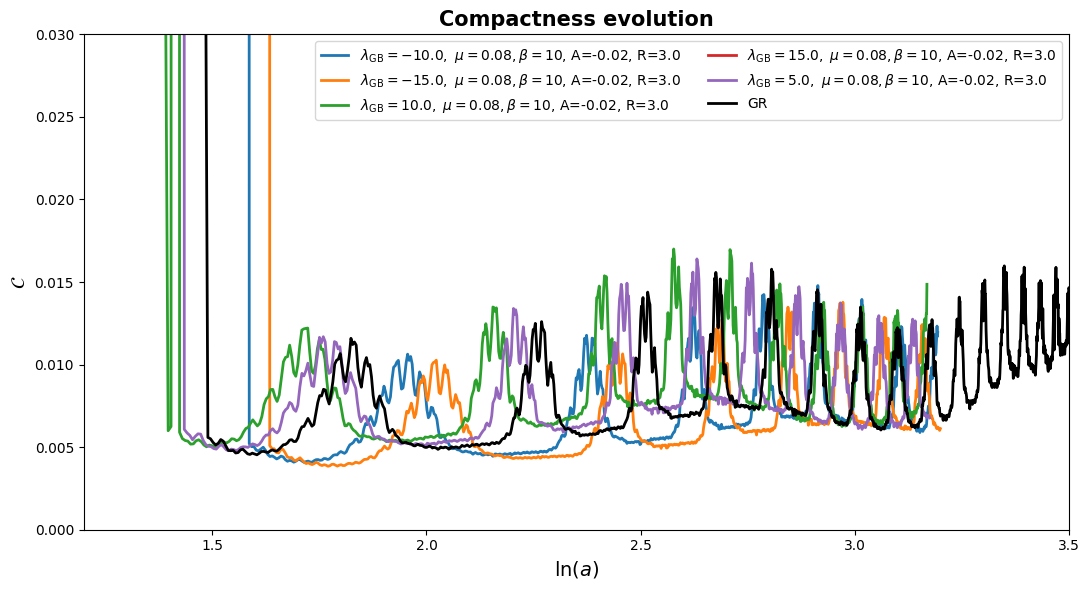

In [131]:
keys_to_plot = sorted(all_runs.keys()) if selected is None else selected

fig, ax = plt.subplots(figsize=(11, 6))

cmap = plt.cm.tab10
for i, key in enumerate(keys_to_plot):
    if key not in all_runs:
        print(f"Key {key} not found, skipping.")
        continue
    data = all_runs[key]
    lgb, mu, beta, amp, width = key
    osc = data["osc"]

    gr_key = (0.0, mu, 250.0, DEFAULT_AMP, DEFAULT_WIDTH)
    gr_data = all_runs[gr_key]
    gr_osc = gr_data["osc"]
    gr_ln_a = gr_osc["ln_a"]
    gr_C = gr_osc["C"]


    beta_str = f", \\beta={int(beta)}" if beta is not None and beta != 250 else ""
    pert_str = f", A={amp}, R={width}"
    if lgb == 0.0:
        label = f"GR, $\\mu={mu}${pert_str}"
    else:
        label = f"$\\lambda_{{\\rm GB}}={lgb},\\ \\mu={mu}{beta_str}${pert_str}"

    ax.plot(osc["ln_a"], osc["C"], color=cmap(i % 10), lw=2, label=label)

ax.plot(gr_ln_a, gr_C, color='k', lw=2, label="GR")

ax.set_xlabel(r"$\ln(a)$", fontsize=14)
ax.set_ylabel(r"$\mathcal{C}$", fontsize=14)

ax.set_xlim(1.2, 3.5)
ax.set_ylim(0,0.03)

ax.set_title("Compactness evolution", fontsize=15, fontweight="bold")
ax.legend(fontsize=10, ncol=2, loc="best")
#ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

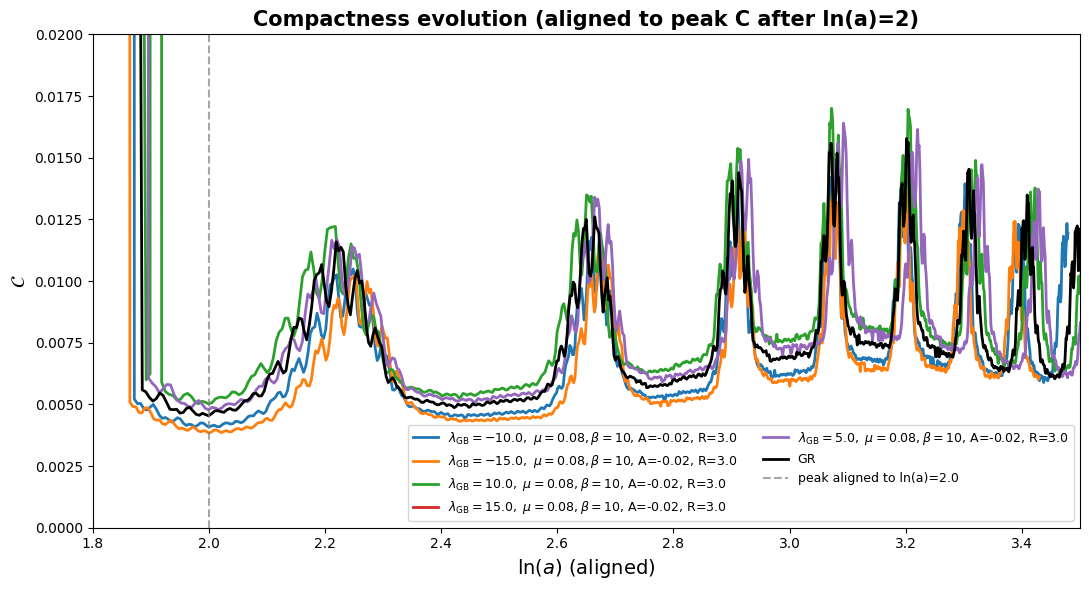

In [132]:
# ── Aligned compactness: shift max C (after ln(a)=2) to a common reference ──
# For each run, find ln(a) of peak compactness for ln(a) > 2, then shift it
# so that peak lands at ALIGN_LNA.

ALIGN_LNA = 2.0  # all peaks get shifted to this ln(a)

def find_peak_lna(osc, lna_min=0):
    """Find ln(a) of maximum compactness after lna_min."""
    C = osc["C"]
    ln_a = osc["ln_a"]
    mask = ln_a > lna_min
    if not np.any(mask):
        return np.nan
    idx = np.where(mask)[0]
    peak = idx[np.argmin(C[idx])]
    return ln_a[peak]

fig, ax = plt.subplots(figsize=(11, 6))
cmap = plt.cm.tab10

for i, key in enumerate(keys_to_plot):
    if key not in all_runs:
        continue
    data = all_runs[key]
    lgb, mu, beta, amp, width = key
    osc = data["osc"]

    gr_key = (0.0, mu, 250.0, DEFAULT_AMP, DEFAULT_WIDTH)
    gr_data = all_runs[gr_key]
    gr_osc = gr_data["osc"]
    gr_ln_a = gr_osc["ln_a"]
    gr_C = gr_osc["C"]

    peak_lna = find_peak_lna(osc)
    shift = ALIGN_LNA - peak_lna if not np.isnan(peak_lna) else 0.0

    beta_str = f", \\beta={int(beta)}" if beta is not None and beta != 250 else ""
    pert_str = f", A={amp}, R={width}"
    if lgb == 0.0:
        label = f"GR, $\\mu={mu}${pert_str}"
    else:
        label = f"$\\lambda_{{\\rm GB}}={lgb},\\ \\mu={mu}{beta_str}${pert_str}"

    ax.plot(osc["ln_a"] + shift, osc["C"], color=cmap(i % 10), lw=2, label=label)

# Plot GR with the same alignment logic
gr_peak = find_peak_lna(gr_osc)
gr_shift = ALIGN_LNA - gr_peak if not np.isnan(gr_peak) else 0.0
ax.plot(gr_ln_a + gr_shift, gr_C, color='k', lw=2, label="GR")

ax.axvline(ALIGN_LNA, color="grey", ls="--", lw=1.5, alpha=0.7, label=f"peak aligned to ln(a)={ALIGN_LNA}")

ax.set_xlabel(r"$\ln(a)$ (aligned)", fontsize=14)
ax.set_ylabel(r"$\mathcal{C}$", fontsize=14)
ax.set_xlim(1.8, 3.5)
ax.set_ylim(0, 2e-2)
ax.set_title("Compactness evolution (aligned to peak C after ln(a)=2)", fontsize=15, fontweight="bold")
ax.legend(fontsize=9, ncol=2, loc="best")
fig.tight_layout()
plt.show()


### 3b — Energy density & Gauss-Bonnet invariant vs radius

For a chosen run, plot $\rho(r)$ at several time snapshots (aligned to the GR formation time).
The **full** Gauss-Bonnet scalar $\mathcal{L}_{\rm GB}(r)$ (including $\partial_\perp K$ and $\partial_\perp A_{ij}$ backreaction terms from the matrix solve) is overlaid on a secondary axis.

**Note:** If `full_L_GB` is not in the saved diagnostics, we recompute from `solution.npy` (this triggers the full BSSN RHS + matrix solve at each output time).

full_L_GB already in diagnostics.


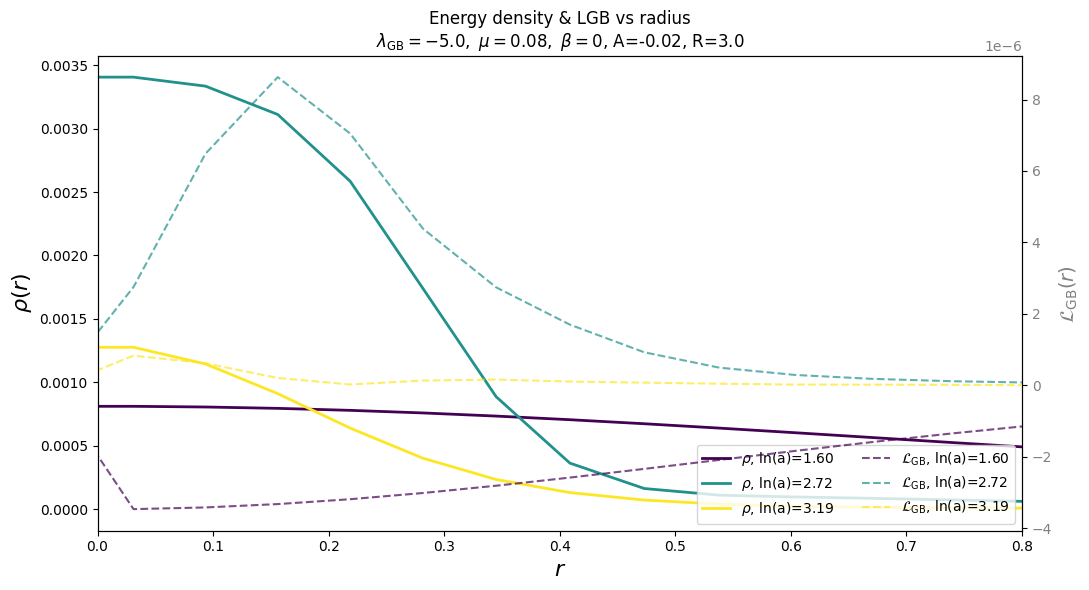

In [133]:
# ── Choose which run to plot energy density & GB invariant for ────────────────
# Pick a key from all_runs; change as needed.
plot_key = (-5.0, 0.08, 0, -0.02, 3.0)   # (lgb, mu, beta, amp, width)

# Also pick the GR reference key for time alignment
gr_ref_key = (0.0, 0.08, 250.0, -0.02, 3.0)

# Number of time snapshots to show (evenly spaced in the post-formation window)
n_snapshots = 3
# Radial range to plot
r_plot_max = 30.0

# ── Load or recompute diagnostics with full_L_GB ─────────────────────────────
run_data = all_runs[plot_key]
osc = run_data["osc"]
r_grid = osc["r"]
ln_a = osc["ln_a"]

has_full_L_GB = "full_L_GB" in osc and np.any(osc["full_L_GB"] != 0)

if not has_full_L_GB:
    print("full_L_GB not in saved diagnostics — recomputing from solution.npy ...")
    lgb_p, mu_p, beta_p, amp_p, width_p = plot_key
    tag = run_data["tag"]
    run_dir = os.path.join(DATA_DIR, tag)

    sol = np.load(os.path.join(run_dir, "solution.npy"))
    t_arr = np.load(os.path.join(run_dir, "t.npy"))

    matter_p = ScalarMatter(scalar_mu, mu_p)
    sv_p = StateVector(matter_p)
    spacing_p = CubicSpacing(**CubicSpacing.get_parameters(r_max, min_dr, max_dr))
    grid_p = Grid(spacing_p, sv_p)
    bg_p = FlatSphericalBackground(grid_p.r)

    coupling_p = run_data["coupling"]
    params_p = (lgb_p, a_mg, b_mg, chi0, coupling_p)

    osc = get_oscillon_diagnostic(
        sol, t_arr, grid_p, bg_p,
        ScalarMatter(scalar_mu, mu_p),
        params_p, surface_threshold=0.05, r_max_diag=100.0,
    )
    np.savez(os.path.join(run_dir, "diagnostics.npz"), **osc)
    run_data["osc"] = osc
    ln_a = osc["ln_a"]
    r_grid = osc["r"]
    del sol
    print("Done. full_L_GB now available.")
else:
    print("full_L_GB already in diagnostics.")

# ── Align time: manual shift (adjust to line up with GR formation) ───────────
time_shift = 0.0  # adjust by hand if needed
aligned_lna = ln_a + time_shift

# ── Select snapshots in post-formation window ────────────────────────────────
post_mask = aligned_lna >= LN_A_COMPACTNESS_MIN
if np.any(post_mask):
    post_indices = np.where(post_mask)[0]
    snap_indices = post_indices[np.linspace(0, len(post_indices)-1, n_snapshots, dtype=int)]
else:
    snap_indices = np.linspace(0, len(ln_a)-1, n_snapshots, dtype=int)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(11, 6))
ax2 = ax1.twinx()

r_mask = r_grid <= r_plot_max
cmap_snap = plt.cm.viridis

for j, idx in enumerate(snap_indices):
    color = cmap_snap(j / max(n_snapshots - 1, 1))
    lna_val = aligned_lna[idx]
    label_rho = f"$\\rho$, ln(a)={lna_val:.2f}"
    label_gb  = f"$\\mathcal{{L}}_{{\\rm GB}}$, ln(a)={lna_val:.2f}"

    ax1.plot(r_grid[r_mask], osc["rho"][idx][r_mask],
             color=color, lw=2, label=label_rho)

    if "full_L_GB" in osc:
        ax2.plot(r_grid[r_mask], osc["full_L_GB"][idx][r_mask],
                 color=color, lw=1.5, ls="--", alpha=0.7, label=label_gb)

lgb_p, mu_p, beta_p, amp_p, width_p = plot_key
ax1.set_xlabel(r"$r$", fontsize=16)
ax1.set_ylabel(r"$\rho(r)$", fontsize=16, color="k")
ax2.set_ylabel(r"$\mathcal{L}_{\rm GB}(r)$ ", fontsize=14, color="gray")
ax2.tick_params(axis="y", labelcolor="gray")

ax1.set_title(
    f"Energy density & LGB vs radius\n"
    f"$\\lambda_{{\\rm GB}}={lgb_p},\\ \\mu={mu_p},\\ \\beta={int(beta_p)}$, "
    f"A={amp_p}, R={width_p}",
    fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, ncol=2, loc="lower right")
ax1.set_xlim(0, 0.8)

fig.tight_layout()
plt.show()

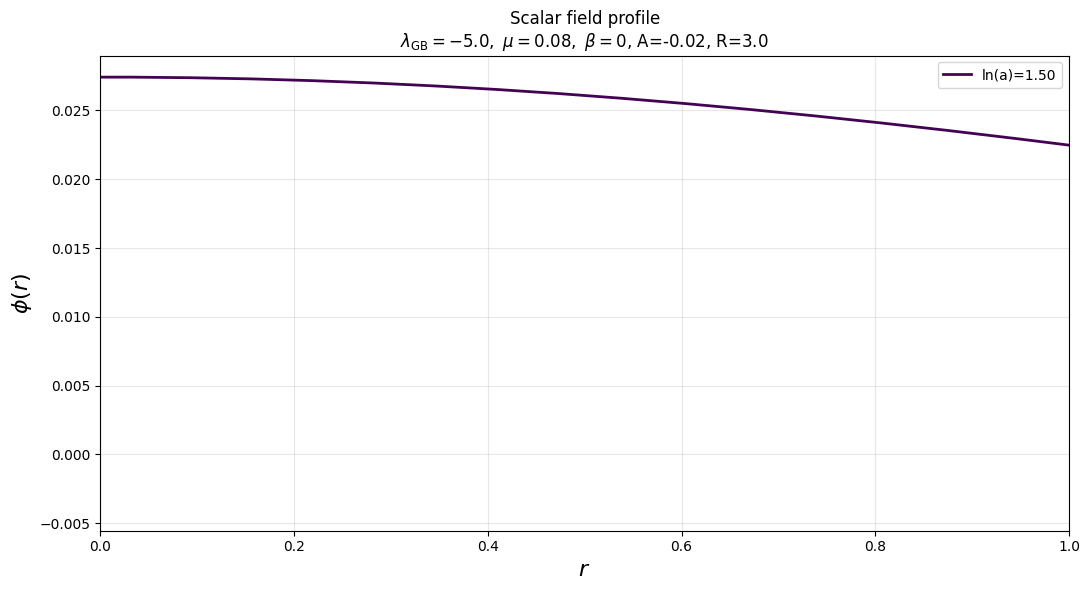

In [134]:
# ── Scalar field φ(r) at the same snapshots as the ρ/L_GB plot above ──────────
# Loads the raw solution to extract u(r,t) at each snapshot time.

# Pick specific ln(a) values
#target_lna = [1.6, 2.0, 2.5, 3.0]
target_lna = [1.5]
snap_indices = [np.argmin(np.abs(aligned_lna - lna)) for lna in target_lna]

lgb_p, mu_p, beta_p, amp_p, width_p = plot_key
tag = run_data["tag"]
run_dir = os.path.join(DATA_DIR, tag)

sol = np.load(os.path.join(run_dir, "solution.npy"))
N_grid = len(r_grid)
NUM_VARS = sol.shape[1] // N_grid

fig, ax = plt.subplots(figsize=(11, 6))
r_mask = r_grid <= r_plot_max
cmap_snap = plt.cm.viridis

for j, idx in enumerate(snap_indices):
    state = sol[idx].reshape(NUM_VARS, N_grid)
    u_field = state[12]  # scalar field u = φ (index 12 = NUM_BSSN_VARS)
    color = cmap_snap(j / max(n_snapshots - 1, 1))
    lna_val = aligned_lna[idx]
    ax.plot(r_grid[r_mask], u_field[r_mask], color=color, lw=2,
            label=f"ln(a)={lna_val:.2f}")

ax.set_xlabel(r"$r$", fontsize=16)
ax.set_ylabel(r"$\phi(r)$", fontsize=16)
ax.set_title(
    f"Scalar field profile\n"
    f"$\\lambda_{{\\rm GB}}={lgb_p},\\ \\mu={mu_p},\\ \\beta={int(beta_p)}$, "
    f"A={amp_p}, R={width_p}",
    fontsize=12)
ax.legend(fontsize=10, loc="best")
ax.set_xlim(0, 1)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

del sol

In [138]:
# ── V(φ) and V_eff(φ) = V(φ) - λ(φ) L_GB ───────────────────────────────────

#lambda_values = [0, 5, 50, 100, -5, -50, -100] 
lambda_values = [0, -10]


lgb_p, mu_p, beta_p, amp_p, width_p = plot_key
m = scalar_mu     # = 1
f = mu_p          # selfinteraction = 0.08

# ── Extract L_GB from simulation at the oscillon center ──────────────────────
snap_idx = snap_indices[1]
r_grid_veff = osc["r"]
center_idx = np.argmin(np.abs(r_grid_veff))
L_GB_center = osc["full_L_GB"][snap_idx, center_idx]
print(f"At snapshot {snap_idx} (ln(a)={ln_a[snap_idx]:.2f}):  L_GB(r=0) = {L_GB_center:.4e}")

# ── Define potentials ────────────────────────────────────────────────────────
phi = np.linspace(-1.0, 0.1, 500)
V = 0.5 * m**2 * f**2 * (1.0 - np.exp(phi / f))**2

fig, ax = plt.subplots(figsize=(10, 6))
cmap_veff = plt.cm.coolwarm

for i, lgb_val in enumerate(lambda_values):
    if beta_p == 0:
        lam_phi = lgb_val * phi**2
    else:
        lam_phi = -lgb_val / beta_p * np.exp(-beta_p * phi**2)

    V_eff = V - lam_phi * L_GB_center

    if lgb_val == 0:
        ax.plot(phi, V_eff, color="black", lw=2.5, label=r"GR ($\lambda_{\rm GB}=0$)")
    else:
        color = cmap_veff(i / max(len(lambda_values) - 1, 1))
        ax.plot(phi, V_eff, color=color, lw=2,
                label=rf"$\lambda_{{\rm GB}}={lgb_val}$", linestyle='--')

ax.set_xlabel(r"$\phi$", fontsize=16)
ax.set_ylabel(r"$V_{\rm eff}(\phi)$", fontsize=16)
ax.set_title(
    r"$V_{\rm eff}(\phi) = V(\phi) - \lambda(\phi)\,\mathcal{L}_{\rm GB}$"
    + f",  $\\beta={int(beta_p)}$,  $\\mu={f}$\n"
    + f"$\\mathcal{{L}}_{{\\rm GB}}(r=0)={L_GB_center:.3e}$"
    + f"  (at ln(a)={ln_a[snap_idx]:.2f})",
    fontsize=12)
ax.legend(fontsize=10, loc="best")
ax.set_xlim(-1, 0.1)
ax.set_ylim(0.0031, 0.00325)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

IndexError: list index out of range

## 4 — Compactness vs $\lambda_{\rm GB}$ at fixed $\beta$

Choose a $\beta$ value; plot mean compactness vs $\lambda_{\rm GB}$ with error bars (min–max) and shaded band. Each curve is a different $\mu$.

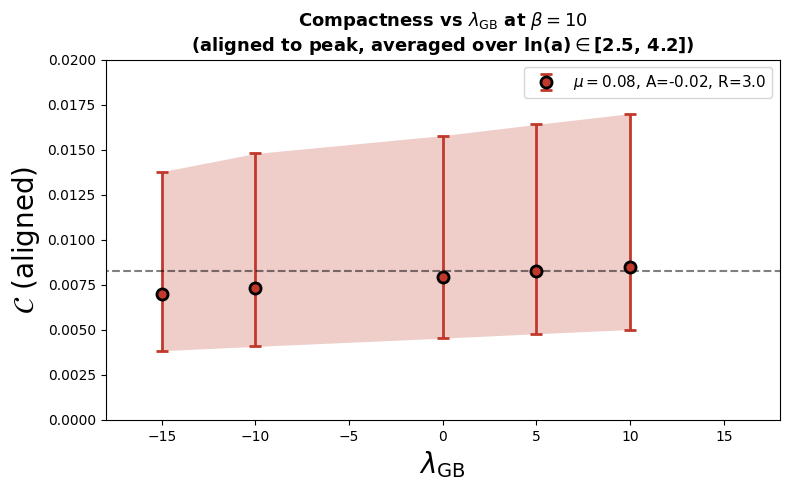

In [145]:
# ── Compactness vs λ_GB using ALIGNED ln(a) window ──────────────────────────
# Same as the plot above, but compactness is computed after shifting each run
# so that its peak C (for ln(a)>2) lands at ALIGN_LNA, then averaging in
# the aligned window [ALIGN_LNA_MIN, ALIGN_LNA_MAX].

ALIGN_LNA = 3
ALIGN_LNA_MIN = 2.5
ALIGN_LNA_MAX = 4.2

def aligned_compactness(osc, lna_min_peak=1.9):
    """Shift peak C to ALIGN_LNA, then compute mean/min/max in aligned window."""
    C = osc["C"]
    ln_a = osc["ln_a"]
    # Find min C after lna_min_peak (same as find_peak_lna in cell above)
    mask_peak = ln_a > lna_min_peak
    if not np.any(mask_peak):
        return np.nan, np.nan, np.nan
    idx_peak = np.where(mask_peak)[0]
    peak_idx = idx_peak[np.argmin(C[idx_peak])]
    shift = ALIGN_LNA - ln_a[peak_idx]
    aligned = ln_a + shift
    # Window in aligned coordinates
    win = (aligned >= ALIGN_LNA_MIN) & (aligned <= ALIGN_LNA_MAX)
    if not np.any(win):
        return np.nan, np.nan, np.nan
    C_win = C[win]
    return np.mean(C_win), np.min(C_win), np.max(C_win)

# Use the same runs as the aligned compactness time series (keys_to_plot)
fig, ax = plt.subplots(figsize=(8, 5))

points = []

# Include GR point (λ_GB=0)
gr_key = (0.0, 0.08, 250.0, DEFAULT_AMP, DEFAULT_WIDTH)
if gr_key in all_runs:
    C_m, C_lo, C_hi = aligned_compactness(all_runs[gr_key]["osc"])
    if not np.isnan(C_m):
        points.append((0.0, C_m, C_lo, C_hi))

for key in keys_to_plot:
    if key not in all_runs or key[0] == 0.0:
        continue
    lgb, mu, beta, amp, width = key
    data = all_runs[key]
    C_m, C_lo, C_hi = aligned_compactness(data["osc"])
    if np.isnan(C_m):
        continue
    points.append((lgb, C_m, C_lo, C_hi))

for idx_mu, mu in enumerate([0.08]):
    if not points:
        continue
    points = sorted(points, key=lambda p: p[0])
    x = np.array([p[0] for p in points])
    y_mean = np.array([p[1] for p in points])
    y_min  = np.array([p[2] for p in points])
    y_max  = np.array([p[3] for p in points])

    color = colors[idx_mu % len(colors)]
    marker = markers[idx_mu % len(markers)]
    label = f"$\\mu = {mu}$, A={DEFAULT_AMP}, R={DEFAULT_WIDTH}"

    ax.fill_between(x, y_min, y_max, color=color, alpha=0.25, linewidth=0)
    yerr_lo = y_mean - y_min
    yerr_hi = y_max - y_mean
    ax.errorbar(
        x, y_mean,
        yerr=[yerr_lo, yerr_hi],
        fmt=marker, color=color, markeredgecolor="k", markeredgewidth=2,
        capsize=4, capthick=1.2, elinewidth=2, markersize=8,
        label=label,
    )

ax.set_xlabel(r"$\lambda_{\rm GB}$", fontsize=20)
ax.set_ylabel(r"$\mathcal{C}$ (aligned)", fontsize=20)
ax.set_title(
    f"Compactness vs $\\lambda_{{\\rm GB}}$ at $\\beta = {selected_beta}$\n"
    f"(aligned to peak, averaged over ln(a)$\\in$[{ALIGN_LNA_MIN}, {ALIGN_LNA_MAX}])",
    fontsize=13, fontweight="bold")
ax.legend(fontsize=11, loc="best")
ax.hlines(C_m, -20, 20, color="k", linestyle="--", alpha=0.5)
ax.set_xlim(-18, 18)
ax.set_ylim(0, 0.02)
fig.tight_layout()
plt.show()

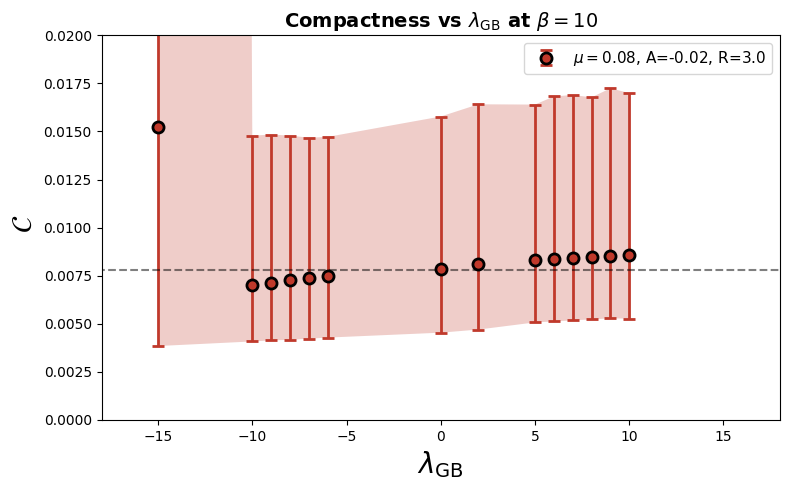

In [146]:
# ── Choose β for compactness vs λ_GB plot ─────────────────────────────────────
selected_beta = betaval   # change to 10, 25, 250, etc. to see available runs

# Filter runs at this beta with default perturbation, and group by (μ, amp, width)
runs_at_beta = [
    (k, all_runs[k]) for k in all_runs
    if k[2] == selected_beta and k[3] == DEFAULT_AMP and k[4] == DEFAULT_WIDTH
]
mus = sorted(set(k[1] for k, _ in runs_at_beta))
mus = [0.08]

# GR (λ_GB = 0) runs: beta irrelevant when lambda=0; use any (lgb=0, mu, default pert) run per μ
gr_runs = {}
for (lgb, mu, beta, amp, width), data in all_runs.items():
    if lgb == 0 and mu in mus and amp == DEFAULT_AMP and width == DEFAULT_WIDTH and mu not in gr_runs:
        gr_runs[mu] = data

# Style: markers and colors like reference (red circles, green triangles, blue squares)
colors = ["#c0392b", "#27ae60", "#2980b9"]
markers = ["o", "v", "s"]
fig, ax = plt.subplots(figsize=(8, 5))

for idx_mu, mu in enumerate(mus):
    points = []
    # Add GR point (λ_GB = 0) for this μ if available
    if mu in gr_runs:
        data = gr_runs[mu]
        C_mean, C_min, C_max = data["C_mean"], data["C_min"], data["C_max"]
        if not np.isnan(C_mean):
            points.append((0.0, C_mean, C_min, C_max))
    for (lgb, mu_k, beta_k, amp_k, width_k), data in runs_at_beta:
        if mu_k != mu:
            continue
        C_mean, C_min, C_max = data["C_mean"], data["C_min"], data["C_max"]
        if np.isnan(C_mean):
            continue
        points.append((lgb, C_mean, C_min, C_max))
    if not points:
        continue
    points = sorted(points, key=lambda p: p[0])
    x = np.array([p[0] for p in points])
    y_mean = np.array([p[1] for p in points])
    y_min = np.array([p[2] for p in points])
    y_max = np.array([p[3] for p in points])

    color = colors[idx_mu % len(colors)]
    marker = markers[idx_mu % len(markers)]
    label = f"$\\mu = {mu}$, A={DEFAULT_AMP}, R={DEFAULT_WIDTH}"

    # Shaded band (min to max)
    ax.fill_between(x, y_min, y_max, color=color, alpha=0.25, linewidth=0)

    # Error bars: I-beam style (min to max)
    yerr_lo = y_mean - y_min
    yerr_hi = y_max - y_mean
    ax.errorbar(
        x, y_mean,
        yerr=[yerr_lo, yerr_hi],
        fmt=marker, color=color, markeredgecolor="k", markeredgewidth=2,
        capsize=4, capthick=1.2, elinewidth=2, markersize=8,
        label=label,
    )

ax.set_xlabel(r"$\lambda_{\rm GB}$", fontsize=20)
ax.set_ylabel(r" $\mathcal{C}$", fontsize=20)
ax.set_title(f"Compactness vs $\\lambda_{{\\rm GB}}$ at $\\beta = {selected_beta}$", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, loc="best")
ax.hlines(0.0078, -20, 20, color="k", linestyle="--", alpha=0.5)
#ax.grid(True, alpha=0.25)
#ax.set_xlim(left=-0.5)
ax.set_xlim(-18, 18)
#ax.set_ylim(bottom=-0.0009)
ax.set_ylim(0,0.02)
fig.tight_layout()
plt.show()

/tmp/ipykernel_4019688/1946664322.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1b.legend(fontsize=10, loc="upper right")
/tmp/ipykernel_4019688/1946664322.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


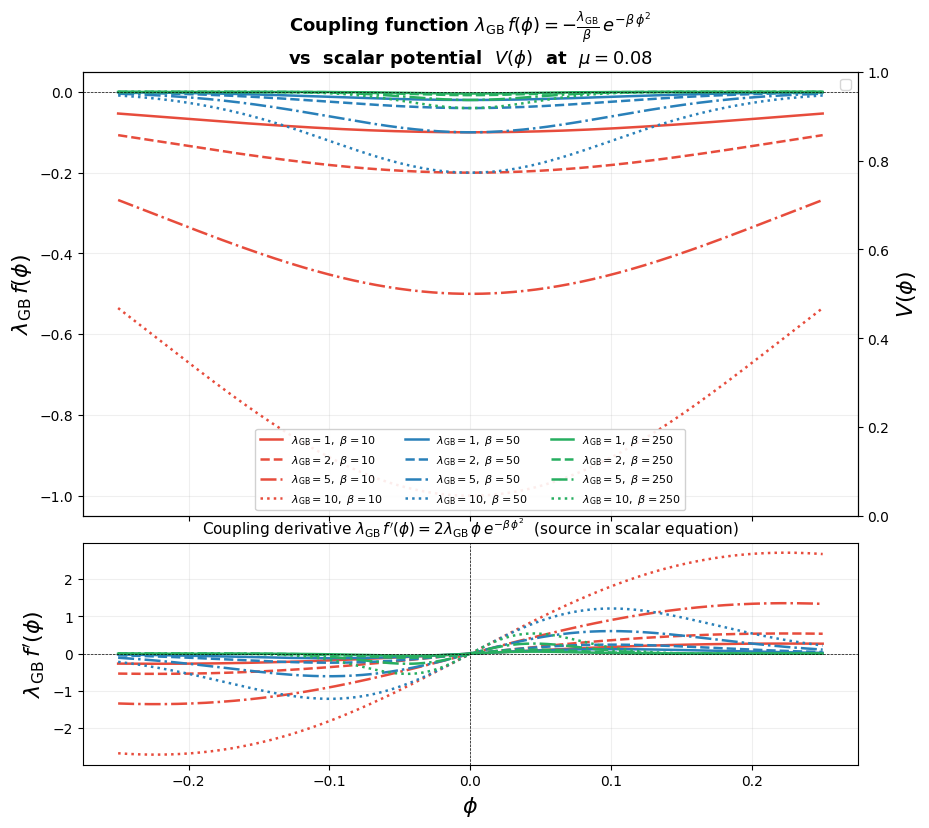

In [101]:
# ── Coupling function f(φ) and scalar potential V(φ) ──────────────────────────
phi = np.linspace(-0.25, 0.25, 500)
m = 1.0       # scalar_mu (mass parameter)
mu = 0.08  # self-interaction

# Coupling: λ_GB * f(φ) = -(λ_GB / β) * exp(-β φ²)
def coupling(phi, lgb, beta):
    return -(lgb / beta) * np.exp(-beta * phi**2)

# Derivative: λ_GB * f'(φ) = 2 λ_GB φ exp(-β φ²)
def dcoupling(phi, lgb, beta):
    return 2.0 * lgb * phi * np.exp(-beta * phi**2)

# Scalar potential: V(φ) = (1/2) m² μ² (1 - exp(φ/μ))²
def potential(phi, m, mu):
    return 0.5 * m**2 * mu**2 * (1.0 - np.exp(phi / mu))**2

# ── Parameters to explore ────────────────────────────────────────────────────
lgb_values = [1, 2, 5, 10]
beta_values = [10, 50, 250]

fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08})

# ── Top panel: coupling λ_GB × f(φ) ──────────────────────────────────────────
ax1 = axes[0]
cmap_beta = {"10": "#e74c3c", "50": "#2980b9", "250": "#27ae60"}
ls_lgb = {1: "-", 2: "--", 5: "-.", 10: ":"}

for beta in beta_values:
    for lgb in lgb_values:
        y = coupling(phi, lgb, beta)
        ax1.plot(phi, y,
                 color=cmap_beta[str(beta)],
                 linestyle=ls_lgb[lgb],
                 linewidth=1.8,
                 label=f"$\\lambda_{{\\rm GB}}={lgb},\\ \\beta={beta}$")

ax1.set_ylabel(r"$\lambda_{\rm GB}\, f(\phi)$", fontsize=16)
ax1.set_title(r"Coupling function $\lambda_{\rm GB}\,f(\phi) = -\frac{\lambda_{\rm GB}}{\beta}\,e^{-\beta\,\phi^2}$"
              + f"\nvs  scalar potential  " + r"$V(\phi)$" + f"  at  $\\mu = {mu}$",
              fontsize=13, fontweight="bold")
ax1.legend(fontsize=8, ncol=3, loc="lower center", framealpha=0.9)
ax1.axhline(0, color="k", lw=0.5, ls="--")
ax1.grid(True, alpha=0.2)

# Overlay V(φ) on secondary y-axis
ax1b = ax1.twinx()
V = potential(phi, m, mu)
#ax1b.plot(phi, V, color="k", linewidth=2.5, alpha=0.7, label=f"$V(\\phi)$, $\\mu={mu}$")
ax1b.set_ylabel(r"$V(\phi)$", fontsize=16, color="k")
ax1b.tick_params(axis="y", labelcolor="k")
ax1b.legend(fontsize=10, loc="upper right")

# ── Bottom panel: derivative λ_GB × f'(φ) (source term in scalar eq.) ────────
ax2 = axes[1]
for beta in beta_values:
    for lgb in lgb_values:
        y = dcoupling(phi, lgb, beta)
        ax2.plot(phi, y,
                 color=cmap_beta[str(beta)],
                 linestyle=ls_lgb[lgb],
                 linewidth=1.8)

ax2.set_xlabel(r"$\phi$", fontsize=16)
ax2.set_ylabel(r"$\lambda_{\rm GB}\, f'(\phi)$", fontsize=16)
ax2.set_title(r"Coupling derivative $\lambda_{\rm GB}\,f'(\phi) = 2\lambda_{\rm GB}\,\phi\,e^{-\beta\,\phi^2}$"
              + "  (source in scalar equation)", fontsize=11)
ax2.axhline(0, color="k", lw=0.5, ls="--")
ax2.axvline(0, color="k", lw=0.5, ls="--")
ax2.grid(True, alpha=0.2)

fig.tight_layout()
plt.show()